## **Imports**

In [ ]:
!pip install keras-tuner -q

In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import regex as re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import shutil
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

# param
CONFIG = {
    "batch_size": 32,
    "max_vocab_size": 10000,
    "max_seq_length": 150,
    "random_state": 42,
    "text_col": "Original_Text",
    "label_col": "Label_Has_PII"
}

## **The data**

In [ ]:
# load the data
df = pd.read_csv("class_df.csv")

df.head()

,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII
0,0,I hope it’s okay to gently share something her...,0.000,1
1,1,The Hanover Company is NOW HIRING! Position: ...,0.000,1
2,2,[#spamton](https://www.facebook.com/hashtag/sp...,0.125,1
3,3,good day everyone! permission to post,0.000,0
4,4,Hiring!Freshers for IT & Non-IT Technologies w...,0.000,1


In [ ]:
print(df.dtypes)
print(df["Label_Has_PII"].value_counts(normalize=True))

Original_DataFrame_Index      int64
Original_Text                object
Exposure_Score              float64
Label_Has_PII                 int64
dtype: object
Label_Has_PII
1    0.878663
0    0.121337
Name: proportion, dtype: float64


--- Character Length Distribution ---
count    15527.000000
mean       432.373865
std        532.735536
min          5.000000
25%        165.000000
50%        281.000000
75%        486.000000
max      11019.000000
Name: Original_Text, dtype: float64

--- Word Count Distribution ---
count    15527.000000
mean        62.177368
std         74.641059
min          1.000000
25%         24.000000
50%         40.000000
75%         71.000000
max       1804.000000
Name: Original_Text, dtype: float64


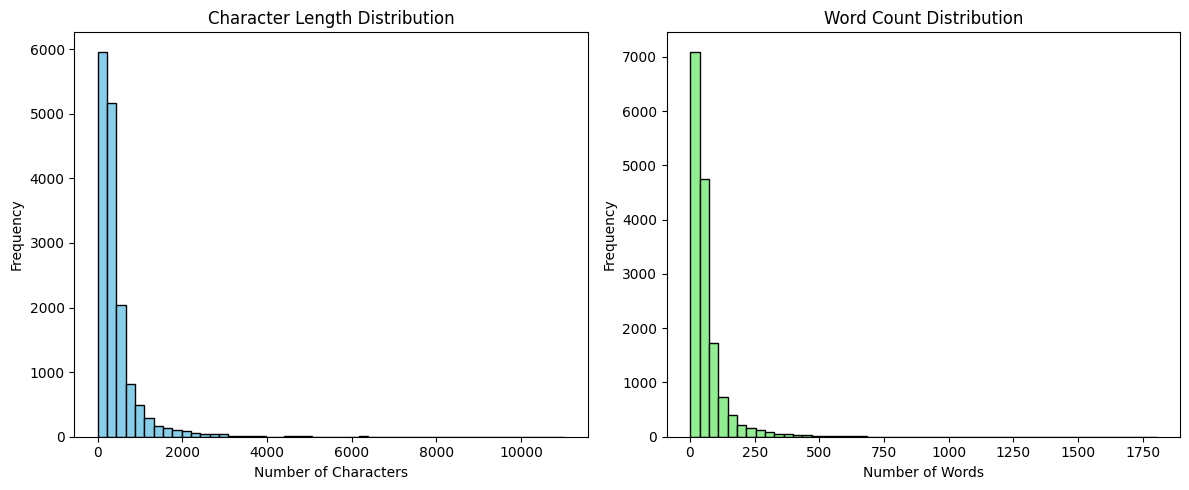

In [ ]:
import matplotlib.pyplot as plt

# Calculate lengths
char_lengths = df["Original_Text"].apply(len)
word_lengths = df["Original_Text"].apply(lambda x: len(str(x).split()))

# Print statistics
print("--- Character Length Distribution ---")
print(char_lengths.describe())
print("\n--- Word Count Distribution ---")
print(word_lengths.describe())

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(char_lengths, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

axes[1].hist(word_lengths, bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## **Feature Engineering**

In [ ]:
# ============================================================================
# FEATURE ENGINEERING (numeric features derived from the raw text)
# ============================================================================
# Two kinds of features:
#   (A) Length/digit statistics  -- cheap, general signal.
#   (B) Structural regex patterns -- catch PII shapes the Bag-of-Words CANNOT
#       see (a phone is a *pattern* of digits, not a vocabulary word).
#
# Patterns were validated on the real data first:
#   - email  : 1,535 posts matched, ~100% are PII  -> KEEP
#   - phone  : 1,053 posts matched (tightened regex), ~100% PII -> KEEP
#   - crypto : only 1 post in the whole dataset     -> DROP (no signal)
#   - coords : 0 posts in any format                -> DROP (not present)
# Redundant math features (sum/avg of digits) were also dropped.
# ============================================================================

# Clean target columns and ensure text is string
df = df.dropna(subset=["Original_Text", "Label_Has_PII"])
df["Original_Text"] = df["Original_Text"].astype(str)

# ---- (A) Length & digit statistics ----------------------------------------
df['word_count']     = df['Original_Text'].apply(lambda x: len(x.split()))
df['char_count']     = df['Original_Text'].apply(lambda x: len(x))
df['log_char_count'] = np.log1p(df['char_count'])          # tame the long tail
df['has_numbers']    = df['Original_Text'].apply(lambda x: 1 if re.search(r'\d', x) else 0)
df['digit_count']    = df['Original_Text'].apply(lambda x: len(re.findall(r'\d', x)))
df['non_digit_count'] = df['char_count'] - df['digit_count']
# Kept (non-linear, not a duplicate of char_count):
df['digits_non_digits_product'] = df['digit_count'] * df['non_digit_count']

# ---- (B) Structural PII patterns (regex) ----------------------------------
# Email: user@domain.tld
EMAIL_RE = re.compile(r'[A-Za-z0-9._%+\-]+@[A-Za-z0-9.\-]+\.[A-Za-z]{2,}')

# Phone: optional +country code, then groups of digits separated by space/./-
# Requiring separators avoids matching prices, dates, long ID strings, etc.
PHONE_RE = re.compile(
    r'(?:\+\d{1,3}[\s.\-]?)?\(?\d{2,4}\)?[\s.\-]\d{2,4}[\s.\-]\d{2,4}(?:[\s.\-]\d{2,4})?'
)

# Count of matches (richer than a 0/1 flag: spam often has several)
df['email_count'] = df['Original_Text'].apply(lambda x: len(EMAIL_RE.findall(x)))
df['phone_count'] = df['Original_Text'].apply(lambda x: len(PHONE_RE.findall(x)))
# Binary presence flags too (sometimes "any" is the cleaner signal)
df['has_email'] = (df['email_count'] > 0).astype(int)
df['has_phone'] = (df['phone_count'] > 0).astype(int)

# ----------------------------------------------------------------------------
# Single source of truth: which numeric features feed the model.
# Edit THIS list to experiment (add/remove in one place).
# ----------------------------------------------------------------------------
NUMERIC_FEATURES = [
    'Exposure_Score',            # original real engagement signal
    'word_count',
    'char_count',
    'log_char_count',
    'has_numbers',
    'digit_count',
    'non_digit_count',
    'digits_non_digits_product',
    'email_count',               # structural PII pattern
    'phone_count',               # structural PII pattern
    'has_email',
    'has_phone',
]

print("Numeric features feeding the model:", len(NUMERIC_FEATURES))
print(NUMERIC_FEATURES)
print("\nFeature statistics:")
display(df[NUMERIC_FEATURES].describe())
display(df.head(3))

Numeric features feeding the model: 12
['Exposure_Score', 'word_count', 'char_count', 'log_char_count', 'has_numbers', 'digit_count', 'non_digit_count', 'digits_non_digits_product', 'email_count', 'phone_count', 'has_email', 'has_phone']

Feature statistics:


,Exposure_Score,word_count,char_count,log_char_count,has_numbers,digit_count,non_digit_count,digits_non_digits_product,email_count,phone_count,has_email,has_phone
count,15527.000000,15527.000000,15527.000000,15527.000000,15527.000000,15527.000000,15527.000000,1.552700e+04,15527.000000,15527.000000,15527.000000,15527.000000
mean,0.393822,62.177368,432.373865,5.645308,0.727120,10.436208,421.937657,1.032256e+04,0.112642,0.073614,0.098860,0.067817
std,0.972509,74.641059,532.735536,0.911365,0.445454,27.580814,520.775794,1.561403e+05,0.360699,0.289458,0.298484,0.251440
min,0.000000,1.000000,5.000000,1.791759,0.000000,0.000000,3.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000000,24.000000,165.000000,5.111988,0.000000,0.000000,159.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,0.375000,40.000000,281.000000,5.641907,1.000000,5.000000,274.000000,1.174000e+03,0.000000,0.000000,0.000000,0.000000
75%,0.625000,71.000000,486.000000,6.188264,1.000000,12.000000,476.000000,4.510000e+03,0.000000,0.000000,0.000000,0.000000
max,66.875000,1804.000000,11019.000000,9.307467,1.000000,1677.000000,10917.000000,1.516343e+07,4.000000,6.000000,1.000000,1.000000


,Original_DataFrame_Index,Original_Text,Exposure_Score,Label_Has_PII,word_count,char_count,log_char_count,has_numbers,digit_count,non_digit_count,digits_non_digits_product,email_count,phone_count,has_email,has_phone
0,0,I hope it’s okay to gently share something her...,0.000,1,136,810,6.698268,0,0,810,0,0,0,0,0
1,1,The Hanover Company is NOW HIRING! Position: ...,0.000,1,157,1059,6.966024,1,21,1038,21798,0,1,0,1
2,2,[#spamton](https://www.facebook.com/hashtag/sp...,0.125,1,32,9351,9.143346,1,1266,8085,10235610,0,0,0,0


## **Stratified Split & Directory Creation**

In [ ]:
# ============================================================================
# STRATIFIED 3-WAY SPLIT  (train / val / test)
# ============================================================================
# Stratified on the label so the natural ~7:1 ratio is preserved in every split.
# After this point: any fitting (vectorizer adapt, scaler fit, class weights,
# oversampling) is done on TRAIN ONLY. val/test keep their natural distribution.
# ============================================================================

from sklearn.model_selection import train_test_split

CONFIG = {
    "batch_size": 32,
    "random_state": 42,
    "text_col": "Original_Text",
    "label_col": "Label_Has_PII",
}

# Split 1: (Train+Val) 85%  vs  Test 15%
train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df[CONFIG['label_col']],
    random_state=CONFIG['random_state'],
)

# Split 2: from the 85%, carve out Val so final ratios are ~70/15/15.
# 0.1765 * 0.85 ≈ 0.15 of the total.
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,
    stratify=train_val_df[CONFIG['label_col']],
    random_state=CONFIG['random_state'],
)

# Reset positional index so text / numeric / labels stay row-aligned downstream.
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# ---- Sanity checks ---------------------------------------------------------
print("Split sizes -> train:", len(train_df),
      "| val:", len(val_df), "| test:", len(test_df))

print("\nLabel ratio per split (should all be ≈ 0.88 / 0.12):")
for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    ratios = d[CONFIG['label_col']].value_counts(normalize=True).round(3).to_dict()
    print(f"  {name:5s}: {ratios}")

# Save for reproducibility / inspection (optional)
train_df.to_csv("train_features.csv", index=True)
val_df.to_csv("val_features.csv", index=True)
test_df.to_csv("test_features.csv", index=True)
print("\nFeature CSVs saved.")

Split sizes -> train: 10867 | val: 2330 | test: 2330

Label ratio per split (should all be ≈ 0.88 / 0.12):
  train: {1: 0.879, 0: 0.121}
  val  : {1: 0.879, 0: 0.121}
  test : {1: 0.879, 0: 0.121}

Feature CSVs saved.


## **TEXT VECTORIZATION for EMBEDDINGS**

In [ ]:
# ============================================================================
# TEXT VECTORIZATION for EMBEDDINGS -- integer sequences (not Bag of Words)
# ============================================================================
# For an Embedding layer we need INTEGER SEQUENCES, not word counts:
#   output_mode='int' + output_sequence_length -> each text becomes a fixed-
#   length sequence of token IDs (padded/truncated). This PRESERVES word order,
#   which is the whole point of moving away from BoW.
# adapt() on TRAIN only (no leakage). Arrays stay row-aligned with numeric+labels.
# ============================================================================

from nltk.stem import SnowballStemmer

MAX_VOCAB_SIZE = 20000
MAX_SEQ_LENGTH = 100       # texts longer than this are truncated; shorter padded
stemmer = SnowballStemmer("english")

def custom_preprocess(text):
    text = text.lower()
    text = re.sub(r'([!@#$%^&*(),.?":{}|<>])', r' \1 ', text)
    tokens = text.split()
    return " ".join(stemmer.stem(w) for w in tokens)

print("Preprocessing text per split...")
train_text = train_df[CONFIG["text_col"]].apply(custom_preprocess).values
val_text   = val_df[CONFIG["text_col"]].apply(custom_preprocess).values
test_text  = test_df[CONFIG["text_col"]].apply(custom_preprocess).values

# ---- Vectorizer: INT sequences, adapt on TRAIN only ------------------------
vectorize_layer = layers.TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',                       # <-- sequences, not counts
    output_sequence_length=MAX_SEQ_LENGTH,   # <-- fixed length (pad/truncate)
    standardize=None,
)

print("Adapting vectorizer on TRAIN text only...")
vectorize_layer.adapt(train_text)
vocab_size = len(vectorize_layer.get_vocabulary())
print("Vocabulary size after adapt:", vocab_size)

# ---- Transform all splits into aligned integer-sequence arrays -------------
X_train_text = vectorize_layer(train_text)
X_val_text   = vectorize_layer(val_text)
X_test_text  = vectorize_layer(test_text)

# Labels aligned with everything else
y_train = train_df[CONFIG["label_col"]].values
y_val   = val_df[CONFIG["label_col"]].values
y_test  = test_df[CONFIG["label_col"]].values

print("\nShapes:")
print("  X_train_text:", X_train_text.shape, "(rows, MAX_SEQ_LENGTH)")
print("  y_train:", y_train.shape)

Preprocessing text per split...
Adapting vectorizer on TRAIN text only...
Vocabulary size after adapt: 20000

Shapes:
  X_train_text: (10867, 100) (rows, MAX_SEQ_LENGTH)
  y_train: (10867,)


## **NUMERIC FEATURE SCALING**

In [ ]:
# ============================================================================
# NUMERIC FEATURE SCALING  (RobustScaler)
# ============================================================================
# Why RobustScaler (not MinMax): the numeric features are heavily right-skewed
# with extreme outliers (e.g. Exposure_Score median=0.38 but max=66.9). MinMax
# would crush ~50% of the data into <1% of the [0,1] range. RobustScaler centers
# on the median and scales by the IQR, so single extreme values barely move it.
#
# Same leakage rule as before: FIT on TRAIN ONLY, then transform val/test.
# Feature set comes from NUMERIC_FEATURES (single source of truth).
# ============================================================================

from sklearn.preprocessing import RobustScaler

# Numeric matrices from the in-memory split DataFrames, same row order as text.
X_train_num_raw = train_df[NUMERIC_FEATURES].values
X_val_num_raw   = val_df[NUMERIC_FEATURES].values
X_test_num_raw  = test_df[NUMERIC_FEATURES].values

# Fit on TRAIN ONLY, then transform all three splits
scaler = RobustScaler()
X_train_num = scaler.fit_transform(X_train_num_raw)   # fit + transform
X_val_num   = scaler.transform(X_val_num_raw)         # transform only
X_test_num  = scaler.transform(X_test_num_raw)        # transform only

print("Numeric features scaled with RobustScaler. Using", len(NUMERIC_FEATURES), "features.")
print("  X_train_num:", X_train_num.shape)
print("  X_val_num:  ", X_val_num.shape)
print("  X_test_num: ", X_test_num.shape)

# ---- Alignment sanity check (text rows must equal numeric rows) ------------
assert X_train_num.shape[0] == X_train_text.shape[0] == y_train.shape[0], "TRAIN misaligned!"
assert X_val_num.shape[0]   == X_val_text.shape[0]   == y_val.shape[0],   "VAL misaligned!"
assert X_test_num.shape[0]  == X_test_text.shape[0]  == y_test.shape[0],  "TEST misaligned!"
print("\nAlignment check passed: text, numeric, and labels are row-synced.")

Numeric features scaled with RobustScaler. Using 12 features.
  X_train_num: (10867, 12)
  X_val_num:   (2330, 12)
  X_test_num:  (2330, 12)

Alignment check passed: text, numeric, and labels are row-synced.


## **DATA BALANCING -- DATA-LEVEL**

### **Prepare Befor Oversampling \ Undersampling**

In [ ]:
# ============================================================================
# DATA BALANCING -- DATA-LEVEL strategies (prepared BEFORE training)
# ============================================================================
# Of the four strategies we compare, only the DATA-LEVEL ones belong here:
#   3. oversampling  -> duplicate minority (class 0) UP to majority size
#   4. undersampling -> cut majority (class 1) DOWN to minority size
#
# The other two are handled elsewhere (chronological honesty):
#   1. baseline      -> nothing to prepare
#   2. class_weights -> COST-LEVEL, computed & applied in the TRAINING block
#
# This cell only PREPARES index arrays; it does NOT touch X_train_text /
# X_train_num / y_train. We resample INDICES so the same selection applies to
# BOTH inputs (text + numeric), keeping them aligned. TRAIN ONLY -- val/test
# keep their natural ~7:1 ratio.
# ============================================================================

np.random.seed(CONFIG['random_state'])

# Positional indices (0..N-1) of each class within the TRAIN set
idx_class_0 = np.where(y_train == 0)[0]   # minority (no PII)
idx_class_1 = np.where(y_train == 1)[0]   # majority (has PII)

n0, n1 = len(idx_class_0), len(idx_class_1)
print(f"TRAIN class sizes -> 0 (minority): {n0} | 1 (majority): {n1}  (ratio 1:{n1/n0:.1f})")

# ---- (3) OVERSAMPLING: duplicate minority up to majority size --------------
# Sample WITH replacement (we need duplicates).
extra_idx = np.random.choice(idx_class_0, size=(n1 - n0), replace=True)
oversampled_indices = np.concatenate([idx_class_0, idx_class_1, extra_idx])
np.random.shuffle(oversampled_indices)   # mix so batches aren't label-ordered

# ---- (4) UNDERSAMPLING: cut majority down to minority size -----------------
# Sample WITHOUT replacement (a unique subset). WARNING: discards data.
kept_majority = np.random.choice(idx_class_1, size=n0, replace=False)
undersampled_indices = np.concatenate([idx_class_0, kept_majority])
np.random.shuffle(undersampled_indices)

# ---- Report ----------------------------------------------------------------
print("\nPrepared data-level index arrays:")
print(f"  oversampled_indices  -> {len(oversampled_indices)} rows "
      f"{pd.Series(y_train[oversampled_indices]).value_counts().sort_index().to_dict()}")
print(f"  undersampled_indices -> {len(undersampled_indices)} rows "
      f"{pd.Series(y_train[undersampled_indices]).value_counts().sort_index().to_dict()}")

TRAIN class sizes -> 0 (minority): 1318 | 1 (majority): 9549  (ratio 1:7.2)

Prepared data-level index arrays:
  oversampled_indices  -> 19098 rows {0: 9549, 1: 9549}
  undersampled_indices -> 2636 rows {0: 1318, 1: 1318}


## **FOCAL LOSS**

In [ ]:
# ============================================================================
# FOCAL LOSS -- a 5th strategy (cost-level), aimed at the hard minority class
# ============================================================================
# Focal loss down-weights easy, already-correct examples (the abundant majority)
# so gradients focus on hard examples (the rare class 0). This can raise class-0
# performance overall, unlike threshold tuning which only trades P for R.
#   gamma: how aggressively to down-weight easy examples (2.0 is standard)
#   alpha: extra weight on the positive class; here we weight the MINORITY.
# Keras requires the loss to be a callable(y_true, y_pred) -- unavoidable.
# ============================================================================

import tensorflow as tf
from tensorflow.keras import backend as K

FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.15   # tune this; higher -> more emphasis on class 1 vs 0

def focal_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
    # p_t = predicted prob of the TRUE class
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    # alpha_t = class-dependent weight
    alpha_t = y_true * FOCAL_ALPHA + (1 - y_true) * (1 - FOCAL_ALPHA)
    # focal term down-weights easy (high p_t) examples
    loss = -alpha_t * K.pow(1 - p_t, FOCAL_GAMMA) * K.log(p_t)
    return K.mean(loss)

print("focal_loss defined. gamma =", FOCAL_GAMMA, "| alpha =", FOCAL_ALPHA)

focal_loss defined. gamma = 2.0 | alpha = 0.15


## **HYBRID MODEL**

In [ ]:
# ============================================================================
# HYBRID MODEL -- Embedding + stacked BiLSTM (text) + numeric features
# ============================================================================
# Fully configurable via MODEL_CONFIG. Text branch supports STACKED BiLSTMs:
#   lstm_layers = [64]      -> one BiLSTM(64)
#   lstm_layers = [64, 32]  -> BiLSTM(64) feeding BiLSTM(32)
# Non-final LSTMs must return_sequences=True (handled automatically).
# ============================================================================

from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

MODEL_CONFIG = {
    "embedding_dim": 128,        # word vector size
    "lstm_layers":   [64],       # one BiLSTM per number; add more to stack
    "text_dropout":  0.3,        # dropout after the text branch
    "num_layers":    [32, 16],   # numeric branch dense layers
    "num_dropout":   0.3,
    "head_layers":   [32],       # fusion head
    "head_dropout":  0.3,
    "learning_rate": 1e-3,
}

text_dim = X_train_text.shape[1]   # = MAX_SEQ_LENGTH
num_dim  = X_train_num.shape[1]
print(f"Sequence length: {text_dim} | vocab: {vocab_size} | numeric dim: {num_dim}")

# ---- Branch A: text (Embedding + stacked BiLSTM) ---------------------------
text_input = layers.Input(shape=(text_dim,), dtype="int32", name="text_input")
x = layers.Embedding(input_dim=vocab_size,
                     output_dim=MODEL_CONFIG["embedding_dim"],
                     mask_zero=True)(text_input)
# Stack BiLSTM layers. Every layer except the LAST returns sequences so the
# next LSTM can read them; the last returns a single vector.
n_lstm = len(MODEL_CONFIG["lstm_layers"])
for i, units in enumerate(MODEL_CONFIG["lstm_layers"]):
    return_seq = (i < n_lstm - 1)      # True for all but the last
    x = layers.Bidirectional(
        layers.LSTM(units, return_sequences=return_seq),
        name=f"bilstm_{i}"
    )(x)
text_repr = layers.Dropout(MODEL_CONFIG["text_dropout"])(x)

# ---- Branch B: numeric -----------------------------------------------------
num_input = layers.Input(shape=(num_dim,), name="numeric_input")
n = num_input
for i, units in enumerate(MODEL_CONFIG["num_layers"]):
    n = layers.Dense(units, activation="relu", name=f"num_dense_{i}")(n)
    if MODEL_CONFIG["num_dropout"] > 0:
        n = layers.Dropout(MODEL_CONFIG["num_dropout"])(n)
num_repr = n

# ---- Fusion + head ---------------------------------------------------------
combined = layers.Concatenate()([text_repr, num_repr])
h = combined
for i, units in enumerate(MODEL_CONFIG["head_layers"]):
    h = layers.Dense(units, activation="relu", name=f"head_dense_{i}")(h)
    if MODEL_CONFIG["head_dropout"] > 0:
        h = layers.Dropout(MODEL_CONFIG["head_dropout"])(h)
output = layers.Dense(1, activation="sigmoid", name="pii_output")(h)

# ---- Assemble & compile ----------------------------------------------------
model = Model(inputs=[text_input, num_input], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=MODEL_CONFIG["learning_rate"]),
    loss="binary_crossentropy", # focal_loss, binary_crossentropy
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")],
)

model.summary()

Sequence length: 100 | vocab: 20000 | numeric dim: 12


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ numeric_input       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense_0 (Dense) │ (None, 32)        │        416 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  2,560,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ num_dense_0[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_0            │ (None, 128)       │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ num_dense_1 (Dense) │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bilstm_0[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ num_dense_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dense_0        │ (None, 32)        │      4,640 │ concatenate[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ head_dense_0[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pii_output (Dense)  │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,664,433 (10.16 MB)

 Trainable params: 2,664,433 (10.16 MB)

 Non-trainable params: 0 (0.00 B)

# Training & Strategy Comparison

## Step A — Comparing Four Balancing Strategies (5 seeds)

Compares `baseline`, `class_weights`, `oversampling`, and `focal_loss` under the
same architecture. Each strategy is run over 5 seeds; the decision threshold is
tuned on VAL to maximize class-0 F1, and we report mean ± std. Goal: determine
whether any strategy is significantly better than the others.

In [ ]:
# ============================================================================
# STEP A -- COMPARE 4 STRATEGIES x 5 SEEDS  (threshold-tuned on VAL)
# ============================================================================
# baseline / class_weights / oversampling / focal_loss (default alpha,gamma).
# Per run: fresh BiLSTM, train, tune threshold on VAL for class-0 F1, record.
# Prereqs in memory: X_*_text, X_*_num, y_*, vocab_size, MODEL_CONFIG, focal_loss,
#                    oversampled_indices  (run the index cell for oversampling!)
# ============================================================================

import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.utils.class_weight import compute_class_weight

STRATEGIES = ["baseline", "class_weights", "oversampling", "focal_loss"]
N_SEEDS    = 5
SEEDS      = list(range(N_SEEDS))
candidate_thresholds = np.linspace(0.05, 0.95, 181)

per_run_rows = []

for strat in STRATEGIES:
    print(f"\n################  {strat}  ################")
    for seed in SEEDS:
        tf.keras.backend.clear_session()
        np.random.seed(seed); tf.random.set_seed(seed)

        # ---- fresh model (matches MODEL_CONFIG) ----
        text_input = layers.Input(shape=(X_train_text.shape[1],), dtype="int32")
        x = layers.Embedding(vocab_size, MODEL_CONFIG["embedding_dim"], mask_zero=True)(text_input)
        n_lstm = len(MODEL_CONFIG["lstm_layers"])
        for i, u in enumerate(MODEL_CONFIG["lstm_layers"]):
            x = layers.Bidirectional(layers.LSTM(u, return_sequences=(i < n_lstm - 1)))(x)
        x = layers.Dropout(MODEL_CONFIG["text_dropout"])(x)
        num_input = layers.Input(shape=(X_train_num.shape[1],))
        nb = num_input
        for u in MODEL_CONFIG["num_layers"]:
            nb = layers.Dense(u, activation="relu")(nb)
            if MODEL_CONFIG["num_dropout"] > 0:
                nb = layers.Dropout(MODEL_CONFIG["num_dropout"])(nb)
        h = layers.Concatenate()([x, nb])
        for u in MODEL_CONFIG["head_layers"]:
            h = layers.Dense(u, activation="relu")(h)
            if MODEL_CONFIG["head_dropout"] > 0:
                h = layers.Dropout(MODEL_CONFIG["head_dropout"])(h)
        out = layers.Dense(1, activation="sigmoid")(h)
        run_model = Model([text_input, num_input], out)

        # ---- strategy -> data + loss + class_weight ----
        fit_cw, loss = None, "binary_crossentropy"
        Xt, Xn, yt = X_train_text, X_train_num, y_train          # baseline default
        if strat == "class_weights":
            w = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
            fit_cw = {0: w[0], 1: w[1]}
        elif strat == "oversampling":
            idx = oversampled_indices
            Xt, Xn, yt = X_train_text.numpy()[idx], X_train_num[idx], y_train[idx]
        elif strat == "focal_loss":
            loss = focal_loss

        run_model.compile(optimizer=tf.keras.optimizers.Adam(MODEL_CONFIG["learning_rate"]),
                          loss=loss, metrics=[tf.keras.metrics.AUC(name="auc")])
        run_model.fit([Xt, Xn], yt,
                      validation_data=([X_val_text, X_val_num], y_val),
                      epochs=20, batch_size=CONFIG["batch_size"], class_weight=fit_cw,
                      callbacks=[EarlyStopping(monitor="val_auc", mode="max",
                                 patience=4, restore_best_weights=True, verbose=0)],
                      verbose=0)

        # ---- tune threshold on VAL for class-0 F1 ----
        val_probs = run_model.predict([X_val_text, X_val_num], verbose=0).ravel()
        c0 = [f1_score(y_val, (val_probs >= t).astype(int), pos_label=0, zero_division=0)
              for t in candidate_thresholds]
        best_t = candidate_thresholds[int(np.argmax(c0))]
        preds = (val_probs >= best_t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(y_val, preds, labels=[0, 1], zero_division=0)
        _, _, fmac, _ = precision_recall_fscore_support(y_val, preds, average="macro", zero_division=0)
        per_run_rows.append({"strategy": strat, "seed": seed, "best_thr": best_t,
                             "c0_prec": p[0], "c0_rec": r[0], "c0_f1": f[0], "macro_f1": fmac})
        print(f"  seed {seed}: thr={best_t:.3f}  c0_F1={f[0]:.4f}  macro_F1={fmac:.4f}")

# ---- results ----
runs_df_A = pd.DataFrame(per_run_rows)
print("\n========  PER-RUN  ========"); display(runs_df_A.round(4))
agg = runs_df_A.groupby("strategy").agg(
    c0_f1_mean=("c0_f1","mean"), c0_f1_std=("c0_f1","std"),
    macro_mean=("macro_f1","mean"), macro_std=("macro_f1","std"),
    c0_rec=("c0_rec","mean"), c0_prec=("c0_prec","mean")).sort_values("c0_f1_mean", ascending=False)
print(f"\n========  SUMMARY (mean ± std, {N_SEEDS} seeds)  ========")
summary_A = pd.DataFrame({
    "class-0 F1": agg["c0_f1_mean"].round(4).astype(str)+" ± "+agg["c0_f1_std"].round(4).astype(str),
    "macro F1":   agg["macro_mean"].round(4).astype(str)+" ± "+agg["macro_std"].round(4).astype(str),
    "c0 recall":  agg["c0_rec"].round(4), "c0 precision": agg["c0_prec"].round(4)})
display(summary_A)
# ---- verdict ----
top, second = agg.index[0], agg.index[1]
gap = agg.loc[top,"c0_f1_mean"] - agg.loc[second,"c0_f1_mean"]
noise = max(agg.loc[top,"c0_f1_std"], agg.loc[second,"c0_f1_std"])
print(f"\nTop: {top} ({agg.loc[top,'c0_f1_mean']:.4f}) | 2nd: {second} ({agg.loc[second,'c0_f1_mean']:.4f})")
print(f"Gap={gap:.4f} | noise≈{noise:.4f}  ->",
      "WITHIN NOISE: pick on principled grounds (favor class_weights)." if gap < noise
      else "Gap exceeds noise: ranking likely real. Still report mean ± std.")
WINNER_A = top
print("WINNER_A =", WINNER_A)


################  baseline  ################
  seed 0: thr=0.575  c0_F1=0.6961  macro_F1=0.8261
  seed 1: thr=0.705  c0_F1=0.6788  macro_F1=0.8155
  seed 2: thr=0.795  c0_F1=0.6882  macro_F1=0.8202
  seed 3: thr=0.720  c0_F1=0.6883  macro_F1=0.8190
  seed 4: thr=0.730  c0_F1=0.6697  macro_F1=0.8071

################  class_weights  ################
  seed 0: thr=0.240  c0_F1=0.6898  macro_F1=0.8230
  seed 1: thr=0.605  c0_F1=0.6999  macro_F1=0.8242
  seed 2: thr=0.205  c0_F1=0.6987  macro_F1=0.8261
  seed 3: thr=0.160  c0_F1=0.6714  macro_F1=0.8128
  seed 4: thr=0.330  c0_F1=0.6886  macro_F1=0.8183

################  oversampling  ################
  seed 0: thr=0.635  c0_F1=0.6822  macro_F1=0.8176
  seed 1: thr=0.305  c0_F1=0.6819  macro_F1=0.8188
  seed 2: thr=0.850  c0_F1=0.6741  macro_F1=0.8115
  seed 3: thr=0.805  c0_F1=0.6714  macro_F1=0.8133
  seed 4: thr=0.710  c0_F1=0.6787  macro_F1=0.8153

################  focal_loss  ################
  seed 0: thr=0.485  c0_F1=0.6954  macro

,strategy,seed,best_thr,c0_prec,c0_rec,c0_f1,macro_f1
0,baseline,0,0.575,0.6699,0.7244,0.6961,0.8261
1,baseline,1,0.705,0.6386,0.7244,0.6788,0.8155
2,baseline,2,0.795,0.6339,0.7527,0.6882,0.8202
3,baseline,3,0.720,0.6110,0.7880,0.6883,0.8190
4,baseline,4,0.730,0.5803,0.7915,0.6697,0.8071
5,class_weights,0,0.240,0.6769,0.7032,0.6898,0.8230
6,class_weights,1,0.605,0.5975,0.8445,0.6999,0.8242
7,class_weights,2,0.205,0.6393,0.7703,0.6987,0.8261
8,class_weights,3,0.160,0.6678,0.6749,0.6714,0.8128
9,class_weights,4,0.330,0.5974,0.8127,0.6886,0.8183



========  SUMMARY (mean ± std, 5 seeds)  ========


,class-0 F1,macro F1,c0 recall,c0 precision
strategy,,,,
class_weights,0.6897 ± 0.0114,0.8209 ± 0.0053,0.7611,0.6358
focal_loss,0.685 ± 0.0074,0.8171 ± 0.0049,0.7837,0.6106
baseline,0.6842 ± 0.0102,0.8176 ± 0.007,0.7562,0.6268
oversampling,0.6777 ± 0.0048,0.8153 ± 0.003,0.7110,0.6496



Top: class_weights (0.6897) | 2nd: focal_loss (0.6850)
Gap=0.0046 | noise≈0.0114  -> WITHIN NOISE: pick on principled grounds (favor class_weights).
WINNER_A = class_weights


## Step B — Focal Loss Tuning (Skipped)

`focal_loss` did not lead in Step A (it placed second, within the noise band), so
tuning its alpha/gamma would mean optimizing a strategy that was not selected.
This step was intentionally skipped — see the rationale in the summary.

## Step C — Architecture Search on the Winning Strategy

Tests targeted variants (BiLSTM width, dropout, fusion head) on `class_weights`,
each over 3 seeds. Goal: confirm that the base architecture is sufficient.

In [ ]:
# ============================================================================
# STEP C -- architecture search on the WINNING strategy. Targeted variants, 3 seeds.
# Set WINNER_STRATEGY from Step A; if focal, set FOCAL_A/FOCAL_G from Step B.
# ============================================================================
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_recall_fscore_support, f1_score
from sklearn.utils.class_weight import compute_class_weight

WINNER_STRATEGY = "class_weights"   # <-- EDIT to Step A winner
FOCAL_A, FOCAL_G = 0.15, 2.0        # <-- used only if winner == focal_loss
C_SEEDS = [0, 1, 2]
candidate_thresholds = np.linspace(0.05, 0.95, 181)

# Targeted architecture variants (name -> config overrides). Keep it small.
VARIANTS = {
    "base   [64] / drop0.3 / head[32]":   dict(lstm_layers=[64], text_dropout=0.3, head_layers=[32], head_dropout=0.3),
    "wider  [128]":                       dict(lstm_layers=[128], text_dropout=0.3, head_layers=[32], head_dropout=0.3),
    "stacked[64,32]":                     dict(lstm_layers=[64,32], text_dropout=0.3, head_layers=[32], head_dropout=0.3),
    "more drop 0.5":                      dict(lstm_layers=[64], text_dropout=0.5, head_layers=[32], head_dropout=0.5),
    "bigger head [64,32]":                dict(lstm_layers=[64], text_dropout=0.3, head_layers=[64,32], head_dropout=0.3),
}
rows_C = []

for name, ov in VARIANTS.items():
    cfg = {**MODEL_CONFIG, **ov}   # override only the keys we vary
    print(f"\n########  {name}  ########")
    for seed in C_SEEDS:
        tf.keras.backend.clear_session()
        np.random.seed(seed); tf.random.set_seed(seed)
        text_input = layers.Input(shape=(X_train_text.shape[1],), dtype="int32")
        x = layers.Embedding(vocab_size, cfg["embedding_dim"], mask_zero=True)(text_input)
        n_lstm = len(cfg["lstm_layers"])
        for i, u in enumerate(cfg["lstm_layers"]):
            x = layers.Bidirectional(layers.LSTM(u, return_sequences=(i < n_lstm-1)))(x)
        x = layers.Dropout(cfg["text_dropout"])(x)
        num_input = layers.Input(shape=(X_train_num.shape[1],))
        nb = num_input
        for u in cfg["num_layers"]:
            nb = layers.Dense(u, activation="relu")(nb)
            if cfg["num_dropout"] > 0: nb = layers.Dropout(cfg["num_dropout"])(nb)
        h = layers.Concatenate()([x, nb])
        for u in cfg["head_layers"]:
            h = layers.Dense(u, activation="relu")(h)
            if cfg["head_dropout"] > 0: h = layers.Dropout(cfg["head_dropout"])(h)
        out = layers.Dense(1, activation="sigmoid")(h)
        run_model = Model([text_input, num_input], out)

        # winning strategy's data + loss
        fit_cw, loss = None, "binary_crossentropy"
        Xt, Xn, yt = X_train_text, X_train_num, y_train
        if WINNER_STRATEGY == "class_weights":
            w = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
            fit_cw = {0: w[0], 1: w[1]}
        elif WINNER_STRATEGY == "oversampling":
            idx = oversampled_indices
            Xt, Xn, yt = X_train_text.numpy()[idx], X_train_num[idx], y_train[idx]
        elif WINNER_STRATEGY == "focal_loss":
            def fl(y_true, y_pred):
                y_true = tf.cast(y_true, tf.float32)
                y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())
                p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
                a_t = y_true*FOCAL_A + (1-y_true)*(1-FOCAL_A)
                return K.mean(-a_t * K.pow(1-p_t, FOCAL_G) * K.log(p_t))
            loss = fl

        run_model.compile(optimizer=tf.keras.optimizers.Adam(cfg["learning_rate"]),
                          loss=loss, metrics=[tf.keras.metrics.AUC(name="auc")])
        run_model.fit([Xt, Xn], yt,
                      validation_data=([X_val_text, X_val_num], y_val),
                      epochs=20, batch_size=CONFIG["batch_size"], class_weight=fit_cw,
                      callbacks=[EarlyStopping(monitor="val_auc", mode="max",
                                 patience=4, restore_best_weights=True, verbose=0)],
                      verbose=0)
        val_probs = run_model.predict([X_val_text, X_val_num], verbose=0).ravel()
        c0 = [f1_score(y_val,(val_probs>=t).astype(int),pos_label=0,zero_division=0) for t in candidate_thresholds]
        best_t = candidate_thresholds[int(np.argmax(c0))]
        preds = (val_probs >= best_t).astype(int)
        p,r,f,_ = precision_recall_fscore_support(y_val, preds, labels=[0,1], zero_division=0)
        rows_C.append({"variant": name, "seed": seed, "c0_f1": f[0]})
        print(f"  seed {seed}: c0_F1={f[0]:.4f}")

runs_df_C = pd.DataFrame(rows_C)
agg_C = runs_df_C.groupby("variant").agg(
    c0_f1_mean=("c0_f1","mean"), c0_f1_std=("c0_f1","std")).sort_values("c0_f1_mean", ascending=False)
print("\n========  architecture variants (mean ± std)  ========"); display(agg_C.round(4))
base_key = [k for k in VARIANTS if k.startswith("base")][0]
base_mean = agg_C.loc[base_key, "c0_f1_mean"]
top_var = agg_C.index[0]; top_mean, top_std = agg_C.iloc[0]["c0_f1_mean"], agg_C.iloc[0]["c0_f1_std"]
print(f"\nBest variant: {top_var} ({top_mean:.4f} ± {top_std:.4f}) | base = {base_mean:.4f}")
print((f">> Adopt '{top_var}' (beats base by more than noise)." if top_mean - base_mean > top_std
       else ">> Improvement WITHIN noise: keep the base architecture (parsimony)."))


########  base   [64] / drop0.3 / head[32]  ########
  seed 0: c0_F1=0.6859
  seed 1: c0_F1=0.6909
  seed 2: c0_F1=0.6743

########  wider  [128]  ########
  seed 0: c0_F1=0.6677
  seed 1: c0_F1=0.7043
  seed 2: c0_F1=0.6845

########  stacked[64,32]  ########
  seed 0: c0_F1=0.6752
  seed 1: c0_F1=0.6900
  seed 2: c0_F1=0.6656

########  more drop 0.5  ########
  seed 0: c0_F1=0.6941
  seed 1: c0_F1=0.6835
  seed 2: c0_F1=0.6866

########  bigger head [64,32]  ########
  seed 0: c0_F1=0.6889
  seed 1: c0_F1=0.6884
  seed 2: c0_F1=0.6755

========  architecture variants (mean ± std)  ========


,c0_f1_mean,c0_f1_std
variant,,
more drop 0.5,0.6881,0.0055
wider [128],0.6855,0.0183
"bigger head [64,32]",0.6843,0.0076
base [64] / drop0.3 / head[32],0.6837,0.0085
"stacked[64,32]",0.6769,0.0123



Best variant: more drop 0.5 (0.6881 ± 0.0055) | base = 0.6837
>> Improvement WITHIN noise: keep the base architecture (parsimony).


## Final Model & Test Evaluation

The strategy and architecture are locked (`class_weights`, base architecture).
The TEST set is opened only here. Protocol: train on TRAIN, lock the threshold on
VAL, then apply the frozen threshold to TEST. 5 seeds → mean ± std. A representative
seed (closest to the mean) is saved as the sealed model.

In [ ]:
# ============================================================================
# FINAL -- train winner (class_weights, base architecture), LOCK threshold on
# VAL, evaluate ONCE on TEST. 5 seeds -> mean ± std. TEST is opened only here.
# ============================================================================
import numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (precision_recall_fscore_support, f1_score,
                             accuracy_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

N_SEEDS = 5
SEEDS   = list(range(N_SEEDS))
candidate_thresholds = np.linspace(0.05, 0.95, 181)
test_rows = []
best_seed_pack = None   # keep the model whose TEST c0-F1 is closest to the mean

for seed in SEEDS:
    tf.keras.backend.clear_session()
    np.random.seed(seed); tf.random.set_seed(seed)

    # ---- base architecture (MODEL_CONFIG, unchanged) ----
    text_input = layers.Input(shape=(X_train_text.shape[1],), dtype="int32")
    x = layers.Embedding(vocab_size, MODEL_CONFIG["embedding_dim"], mask_zero=True)(text_input)
    n_lstm = len(MODEL_CONFIG["lstm_layers"])
    for i, u in enumerate(MODEL_CONFIG["lstm_layers"]):
        x = layers.Bidirectional(layers.LSTM(u, return_sequences=(i < n_lstm-1)))(x)
    x = layers.Dropout(MODEL_CONFIG["text_dropout"])(x)
    num_input = layers.Input(shape=(X_train_num.shape[1],))
    nb = num_input
    for u in MODEL_CONFIG["num_layers"]:
        nb = layers.Dense(u, activation="relu")(nb)
        if MODEL_CONFIG["num_dropout"] > 0: nb = layers.Dropout(MODEL_CONFIG["num_dropout"])(nb)
    h = layers.Concatenate()([x, nb])
    for u in MODEL_CONFIG["head_layers"]:
        h = layers.Dense(u, activation="relu")(h)
        if MODEL_CONFIG["head_dropout"] > 0: h = layers.Dropout(MODEL_CONFIG["head_dropout"])(h)
    out = layers.Dense(1, activation="sigmoid")(h)
    run_model = Model([text_input, num_input], out)

    # ---- winning strategy: class_weights, train on TRAIN only ----
    w = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
    fit_cw = {0: w[0], 1: w[1]}
    run_model.compile(optimizer=tf.keras.optimizers.Adam(MODEL_CONFIG["learning_rate"]),
                      loss="binary_crossentropy", metrics=[tf.keras.metrics.AUC(name="auc")])
    run_model.fit([X_train_text, X_train_num], y_train,
                  validation_data=([X_val_text, X_val_num], y_val),
                  epochs=20, batch_size=CONFIG["batch_size"], class_weight=fit_cw,
                  callbacks=[EarlyStopping(monitor="val_auc", mode="max",
                             patience=4, restore_best_weights=True, verbose=0)],
                  verbose=0)

    # ---- STEP 1: tune threshold on VAL (max class-0 F1), then LOCK it ----
    val_probs = run_model.predict([X_val_text, X_val_num], verbose=0).ravel()
    c0_val = [f1_score(y_val,(val_probs>=t).astype(int),pos_label=0,zero_division=0) for t in candidate_thresholds]
    locked_thr = candidate_thresholds[int(np.argmax(c0_val))]

    # ---- STEP 2: apply the LOCKED threshold to TEST (no tuning on test!) ----
    test_probs = run_model.predict([X_test_text, X_test_num], verbose=0).ravel()
    test_preds = (test_probs >= locked_thr).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y_test, test_preds, labels=[0,1], zero_division=0)
    _, _, fmac, _ = precision_recall_fscore_support(y_test, test_preds, average="macro", zero_division=0)
    acc = accuracy_score(y_test, test_preds)
    test_rows.append({"seed": seed, "locked_thr": locked_thr,
                      "c0_prec": p[0], "c0_rec": r[0], "c0_f1": f[0],
                      "c1_f1": f[1], "macro_f1": fmac, "accuracy": acc})
    print(f"seed {seed}: thr={locked_thr:.3f}  TEST c0_F1={f[0]:.4f}  macro_F1={fmac:.4f}  acc={acc:.4f}")
    best_seed_pack = best_seed_pack or {}
    best_seed_pack[seed] = (run_model, test_preds, locked_thr)

# ============================================================================
# FINAL REPORT
# ============================================================================
test_df_res = pd.DataFrame(test_rows)
print("\n========  TEST -- per seed  ========"); display(test_df_res.round(4))

mean_c0, std_c0 = test_df_res["c0_f1"].mean(), test_df_res["c0_f1"].std()
mean_mac, std_mac = test_df_res["macro_f1"].mean(), test_df_res["macro_f1"].std()
print("\n========  FINAL TEST RESULTS (mean ± std, "
      f"{N_SEEDS} seeds)  ========")
print(f"  class-0 F1 : {mean_c0:.4f} ± {std_c0:.4f}")
print(f"  macro  F1  : {mean_mac:.4f} ± {std_mac:.4f}")
print(f"  c0 recall  : {test_df_res['c0_rec'].mean():.4f}")
print(f"  c0 precision:{test_df_res['c0_prec'].mean():.4f}")
print(f"  accuracy   : {test_df_res['accuracy'].mean():.4f}")

# ---- representative seed (TEST c0-F1 closest to the mean) -> for the writeup ----
rep_seed = int((test_df_res["c0_f1"] - mean_c0).abs().idxmin())
rep_seed = int(test_df_res.loc[rep_seed, "seed"])
rep_model, rep_preds, rep_thr = best_seed_pack[rep_seed]
print(f"\nRepresentative seed = {rep_seed} (closest to mean). Locked threshold = {rep_thr:.3f}")
print("\nConfusion matrix (TEST, representative seed) [rows=true 0/1, cols=pred 0/1]:")
print(confusion_matrix(y_test, rep_preds, labels=[0,1]))
print("\nClassification report (TEST, representative seed):")
print(classification_report(y_test, rep_preds, labels=[0,1],
                            target_names=["class 0 (clean)", "class 1 (PII)"], digits=4))

# ---- save the final sealed model ----
rep_model.save("FINAL_model_class_weights.keras")
print(f"\nFinal model saved: FINAL_model_class_weights.keras  (seed {rep_seed}, thr {rep_thr:.3f})")

seed 0: thr=0.380  TEST c0_F1=0.6715  macro_F1=0.8070  acc=0.9021
seed 1: thr=0.340  TEST c0_F1=0.6686  macro_F1=0.8047  acc=0.8996
seed 2: thr=0.450  TEST c0_F1=0.6544  macro_F1=0.7963  acc=0.8953
seed 3: thr=0.190  TEST c0_F1=0.6512  macro_F1=0.7975  acc=0.9030
seed 4: thr=0.330  TEST c0_F1=0.6697  macro_F1=0.8078  acc=0.9069

========  TEST -- per seed  ========


,seed,locked_thr,c0_prec,c0_rec,c0_f1,c1_f1,macro_f1,accuracy
0,0,0.38,0.5669,0.8233,0.6715,0.9425,0.8070,0.9021
1,1,0.34,0.5579,0.8339,0.6686,0.9408,0.8047,0.8996
2,2,0.45,0.5461,0.8163,0.6544,0.9383,0.7963,0.8953
3,3,0.19,0.5781,0.7456,0.6512,0.9437,0.7975,0.9030
4,4,0.33,0.5882,0.7774,0.6697,0.9458,0.8078,0.9069



========  FINAL TEST RESULTS (mean ± std, 5 seeds)  ========
  class-0 F1 : 0.6631 ± 0.0095
  macro  F1  : 0.8026 ± 0.0054
  c0 recall  : 0.7993
  c0 precision:0.5674
  accuracy   : 0.9014

Representative seed = 1 (closest to mean). Locked threshold = 0.340

Confusion matrix (TEST, representative seed) [rows=true 0/1, cols=pred 0/1]:
[[ 236   47]
 [ 187 1860]]

Classification report (TEST, representative seed):
                 precision    recall  f1-score   support

class 0 (clean)     0.5579    0.8339    0.6686       283
  class 1 (PII)     0.9754    0.9086    0.9408      2047

       accuracy                         0.8996      2330
      macro avg     0.7666    0.8713    0.8047      2330
   weighted avg     0.9247    0.8996    0.9078      2330


Final model saved: FINAL_model_class_weights.keras  (seed 1, thr 0.340)


# Experiment Summary

## The Task
Binary classification of posts: does the text expose PII (1) or is it clean (0)?
Severe class imbalance: ~88% class 1, ~12% class 0. The minority class (0) is the
harder one and is the focus of optimization.

## Metric Choice
For an imbalanced problem the right headline metric is **macro-F1**, with **class-0
F1** as the targeted objective. Majority-class metrics (accuracy, precision on class 1)
are saturated by the imbalance and fail to discriminate between strategies.

## Key Findings
- The four balancing strategies produced class-0 F1 in the range 0.678–0.690 on VAL (5 seeds).
- The gap between strategies (~0.012) is smaller than the run-to-run variance (~0.011)
  → **the strategies are statistically equivalent**.
- The architecture search (Step C) did not exceed the noise band → the base architecture is sufficient.
- Conclusion: the ceiling (~0.69) reflects a **data information limit**, not a limitation
  of the balancing strategy or the architecture.

## Selected Model
`class_weights` on the base architecture — chosen on principled grounds: it preserves
the data distribution, requires no extra hyperparameters, and led on both metrics
(albeit not significantly).

## Final Result (TEST, 5 seeds)
- **class-0 F1: 0.6631 ± 0.0095**
- **macro-F1: 0.8026 ± 0.0054**
- class-0 recall: 0.799 | class-0 precision: 0.567 | accuracy: 0.901

The closeness between VAL (~0.69) and TEST (~0.66) indicates there was no overfitting
to VAL across the tuning steps.